<a href="https://colab.research.google.com/github/jbkim900/Big-data-Analysis-Class_2026.03.12/blob/main/13%EC%9E%A5_%ED%85%8D%EC%8A%A4%ED%8A%B8%EB%A7%88%EC%9D%B4%EB%8B%9D_2026_04_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 13장. 텍스트마이닝_감성분석과 토픽분석

# 1부. 감성 분석 모델링 ================================

## 데이터 수집

### : 깃허브에서 데이터 파일 다운로드 : https://github.com/e9t/nsmc¶

# 4. 데이터 준비 및 탐색

## 4.1 훈련용 데이터 준비하기

### (1) 훈련용 데이터 파일 로드하고 정보 확인하기

In [1]:
import pandas as pd

In [3]:
nsmc_train_df = pd.read_csv('ratings_train.txt', encoding = 'utf8', sep = '\t', engine = 'python')
nsmc_train_df.head() #작업 확인용 출력

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [4]:
nsmc_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


### (2) 결측치 제거하고,  긍정(1)/부정(0) 레이블 분포 확인하기

In [5]:
nsmc_train_df = nsmc_train_df[nsmc_train_df['document'].notnull()]

In [6]:
nsmc_train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149995 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        149995 non-null  int64 
 1   document  149995 non-null  object
 2   label     149995 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ MB


In [7]:
nsmc_train_df['label'].value_counts()

,count
label,
0,75170
1,74825


### (3) 한글 외의 문자 제거하기

In [8]:
import re

In [9]:
nsmc_train_df['document'] = nsmc_train_df['document'].apply(lambda x : re.sub(r'[^ ㄱ-ㅣ가-힣]+', " ", x))
nsmc_train_df.head()   #작업 확인용 출력

,id,document,label
0,9976970,아 더빙 진짜 짜증나네요 목소리,0
1,3819312,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


## 4.2 평가용 데이터 준비하기

### - ratings_test.txt 파일을 로드하여,  4.1 훈련용 데이터 준비과정 반복하기

### (1) 평가용 데이터 파일 로드하고 정보 확인하기

In [11]:
nsmc_test_df = pd.read_csv('ratings_test.txt', encoding= 'utf8', sep = '\t', engine = 'python')
nsmc_test_df.head()  #작업 확인용 출력

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [12]:
nsmc_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        50000 non-null  int64 
 1   document  49997 non-null  object
 2   label     50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


### (2) 결측치 제거하고, 긍정(1)/부정(0) 레이블 분포 확인하기

In [13]:
#document 칼럼이 Null인 샘플 제거
nsmc_test_df = nsmc_test_df[nsmc_test_df['document'].notnull()]

In [14]:
nsmc_test_df['label'].value_counts()

,count
label,
1,25171
0,24826


### (3) 한글 외의 문자 제거하기

In [15]:
nsmc_test_df['document'] = nsmc_test_df['document'].apply(lambda x : re.sub(r'[^ ㄱ-ㅣ가-힣]+', " ", x))

# 5. 분석 모델 구축

## 5.1 특성 벡터화 작업하기

### (1) 형태소를 분석하여 토큰화 : 한글 형태소 엔진으로 Okt 이용

In [17]:
!pip install konlpy
from konlpy.tag import Okt

okt = Okt()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 30.3 MB/s eta 0:00:00


In [18]:
def okt_tokenizer(text):
    tokens = okt.morphs(text)
    return tokens

###### (2) TF-IDF 기반 피처 벡터 생성 : 실행시간 5~10분 정도 걸립니다 ☺

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(tokenizer=okt_tokenizer, ngram_range=(1, 2), min_df=3, max_df=0.9, token_pattern=None)
tfidf.fit(nsmc_train_df['document'])
nsmc_train_tfidf = tfidf.transform(nsmc_train_df['document'])

## 5.2 감성 분류 모델 구축하기

### - 로지스틱 회귀 모델을 이용하여 긍정과 부정의 감성 이진 분류 모델 구축

### (1) 로지스틱 회귀 기반 분석모델 생성

In [20]:
from sklearn.linear_model import LogisticRegression

SA_lr = LogisticRegression(random_state = 0,  max_iter=500)

In [21]:
SA_lr.fit(nsmc_train_tfidf, nsmc_train_df['label'])

LogisticRegression(max_iter=500, random_state=0)

### (2) 로지스틱 회귀의 best 하이퍼파라미터 찾기

In [22]:
from sklearn.model_selection import GridSearchCV

params = {'C': [1, 3, 3.5, 4, 4.5, 5]}
SA_lr_grid_cv = GridSearchCV(SA_lr, param_grid=params, cv=3, scoring='accuracy', verbose = 1)

In [23]:
SA_lr_grid_cv.fit(nsmc_train_tfidf, nsmc_train_df['label'])

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=500, random_state=0),
             param_grid={'C': [1, 3, 3.5, 4, 4.5, 5]}, scoring='accuracy',
             verbose=1)

In [24]:
print(SA_lr_grid_cv.best_params_, round(SA_lr_grid_cv.best_score_, 4))

{'C': 3.5} 0.8553


In [25]:
# 최적 파라미터의 best 모델 저장
SA_lr_best = SA_lr_grid_cv.best_estimator_

# 6. 분석 모델 평가

## 6.1 평가용 데이터를 이용하여 모델 정확도 확인하기

In [26]:
#평가용 데이터의 피처 벡터화
nsmc_test_tfidf = tfidf.transform(nsmc_test_df['document'])

In [27]:
test_predict = SA_lr_best.predict(nsmc_test_tfidf)

In [28]:
from sklearn.metrics import accuracy_score

print('감성 분석 정확도 : ', round(accuracy_score(nsmc_test_df['label'],test_predict), 3))

감성 분석 정확도 :  0.858


## 6.2 새로운 텍스트로 감성 예측 확인하기

In [29]:
st = input('감성 분석할 문장 입력 >> ')

감성 분석할 문장 입력 >> 오늘 날씨가 화창하네


In [30]:
#0) 입력 텍스트에 대한 전처리 수행
st = re.compile(r'[ㄱ-ㅣ가-힣]+').findall(st)
print(st)
st = [" ".join(st)]
print(st)

['오늘', '날씨가', '화창하네']
['오늘 날씨가 화창하네']


In [31]:
#1) 입력 텍스트의 피처 벡터화
st_tfidf = tfidf.transform(st)

#2) 최적 감성 분석 모델에 적용하여 감성 분석 평가
st_predict = SA_lr_best.predict(st_tfidf)

In [32]:
#3) 예측값 출력하기
if(st_predict == 0):
    print(st , "->> 부정 감성")
else :
    print(st , "->> 긍정 감성")

['오늘 날씨가 화창하네'] ->> 긍정 감성


# 2부. 감성 분석 수행 ============================

In [35]:
import json

file_name = '챗GPT_naver_news'

with open(f'/content/챗GPT_naver_news.json', encoding = 'utf-8') as j_f:
    data = json.load(j_f)

In [ ]:
print(data)

[{'cnt': 1, 'description': "특히, 오픈AI가 개발한 <b>챗GPT</b>를 통해 신제품 아이디어를 구상하고 생성형 AI로 제품 비주얼까지 그려내는 차세대 상품 개발 모델 '배스킨라빈스 AI NPD(New Product Development) 시스템'을 최초로 시범 운영한다. 워크샵... ", 'link': 'http://www.thefirstmedia.net/news/articleView.html?idxno=139133', 'org_link': 'http://www.thefirstmedia.net/news/articleView.html?idxno=139133', 'pDate': '2024-02-20 20:04:00', 'title': "SPC 배스킨라빈스, AI 활용한 차세대 혁신매장 '워크샵(Workshop)' 오픈"}, {'cnt': 2, 'description': '<b>챗GPT</b> 개발사 오픈AI와 마이크로소프트(MS)가 대상이다. 생성형AI를 훈련하는 과정에서 자사 저작물을 무단 사용했다는 주장이다. 미국의 언론사가 AI 기업을 상대로 저작권 소송을 제기한 건 처음이다. 대규모 언어 모델... ', 'link': 'https://www.inews365.com/news/article.html?no=802297', 'org_link': 'https://www.inews365.com/news/article.html?no=802297', 'pDate': '2024-02-20 19:48:00', 'title': '언론과 AI의 상생 윈윈 지혜 필요하다'}, {'cnt': 3, 'description': '유아·초등학생 대상 △자녀와 함께하는 말랑말랑 그림책놀이 △책이랑 놀아요 △예술융합상상놀이터 △세계문화유산 왕릉에서 보물 찾기, 성인 대상 △<b>챗GPT</b>와 캔바로 나도 디자이너 △캘리그라피와 플러스펜... ', 'link': 'https://www.ccdn.co.kr/news/articleView.html?idxno=9611

In [36]:
data_title = []
data_description = []
for item in data:
    data_title.append(item['title'])
    data_description.append(item['description'])

In [37]:
data_title  #작업 확인용 출력

["SPC 배스킨라빈스, AI 활용한 차세대 혁신매장 '워크샵(Workshop)' 오픈",
 '언론과 AI의 상생 윈윈 지혜 필요하다',
 '배움으로 삶을 풍요롭게 가꾸는 부여도서관 평생교육 수강생 모집',
 "충북도, AI 도정 실현 첫 걸음 '도공' 운영",
 "육군, '디지털 대전환 선포!'...데이터 중심으로 '정보공유·협업체계' 구축",
 '[주식마감기사] 초전도체 기대감에 신성델타테크 상한가... 비상교육, , 솔브...',
 '머스크, 오픈AI에 또 견제구 &quot;비윤리·불법적으로 보였다&quot;',
 '머스크도 &quot;인류 끝났다&quot;…영상도 만드는 AI, 삼성·하이닉스 웃는다',
 '[Special] 2024 여행 트렌드 &amp; 잘파세대 여행 설명서',
 'GIST, AI·<b>챗GPT</b> 교육 챌린지 개최',
 '&quot;반도체, 우리도 만든다&quot;…고급 인재 쓸어담는 LG전자',
 "현장 안전부터 미래 신사업까지… 'AI 기술' 전면 활용 [스마트 건설시대 여는...",
 "KB증권, 금융권 최초 <b>GPT</b>스토어에 'KB증권 <b>GPT</b>' 출시",
 '다시 샌프란시스코行… AI 붐에 美테크 본사·CEO 재집결',
 "호남대 '인공지능 큐브 PLUS 프로그램' 추진 위한 기획회의 개최",
 '&quot;AI로 기업 투자정보 추출해 뉴스화&quot;…에프앤가이드, 특허 취득',
 '배스킨이 만든 ‘와사비맛 아이스크림’…국내 유일 여기서만 맛본다는데',
 "&quot;<b>챗GPT</b>, KB리서치 추천 주식 알려줘&quot;…금융권 최초 'AI 챗봇' 등장",
 '일론 머스크 “오픈AI 지분 제안받았지만, 비윤리적이라 거절”',
 '[인터뷰] “퇴직해도 <b>챗GPT</b> 활용해 맞춤법 검사기 성능 높일 터”',
 "&quot;엔비디아 아성 깨자&quot;… 삼성 'AI 슈퍼칩' 경쟁 불붙였다",
 '동양레이더/부여도서관 평생교육 수강생 모집',
 '심심할 틈이 없다! <b>챗GPT</b> 탑재한

In [38]:
data_description #작업 확인용 출력

["특히, 오픈AI가 개발한 <b>챗GPT</b>를 통해 신제품 아이디어를 구상하고 생성형 AI로 제품 비주얼까지 그려내는 차세대 상품 개발 모델 '배스킨라빈스 AI NPD(New Product Development) 시스템'을 최초로 시범 운영한다. 워크샵... ",
 '<b>챗GPT</b> 개발사 오픈AI와 마이크로소프트(MS)가 대상이다. 생성형AI를 훈련하는 과정에서 자사 저작물을 무단 사용했다는 주장이다. 미국의 언론사가 AI 기업을 상대로 저작권 소송을 제기한 건 처음이다. 대규모 언어 모델... ',
 '유아·초등학생 대상 △자녀와 함께하는 말랑말랑 그림책놀이 △책이랑 놀아요 △예술융합상상놀이터 △세계문화유산 왕릉에서 보물 찾기, 성인 대상 △<b>챗GPT</b>와 캔바로 나도 디자이너 △캘리그라피와 플러스펜... ',
 '도공에 참여하는 공무원들은 <b>챗GPT</b> 등을 활용해 문서나 이미지, 영상물 등을 제작하는 것부터 시작해서 생성형 AI를 활용한 챗봇 제작 등 대도민 서비스에 적용하기 위한 심화학습을 이어나갈 예정이다. 이밖에 도민... ',
 "기반 국방데이터 활용 활성화 방안', 하정우 디지털플랫폼정부위원회 인공지능·데이터 분과위원장의 '<b>챗GPT</b> 1년, 초거대 AI 전쟁 시대의 국방'을 주제로 한 강연이 진행됐다. 박안수 총장은 &quot;디지털 대전환은 '첨단... ",
 "<b>챗GPT</b> 개발사 오픈AI가 공개한 인공지능 영상제작 프로그램 '소라(SORA)'는 텍스트만으로 동영상을 생성할 수 있고 기존의 이미지를 동영상으로 만들 수 있다. 또한 기존 프로그램과 달리, 어색함이 거의 없고... ",
 '&quot; 일론 머스크 테슬라 최고경영자(CEO)가 생성형 인공지능(AI) <b>챗GPT</b> 개발사인 오픈AI에 또다시 견제구를... 머스크는 앞서 같은 해 4월 AI 개발 계획을 발표하면서 &quot;<b>챗GPT</b>가 정치적으로 타당하도록&quot; 훈련돼 &quot;진실하지 않은... ',
 '“gg 

In [39]:
data_df = pd.DataFrame({'title':data_title, 'description':data_description})

In [40]:
data_df['title'] = data_df['title'].apply(lambda x : re.sub(r'[^ ㄱ-ㅣ가-힣]+', " ", x))
data_df['description'] = data_df['description'].apply(lambda x : re.sub(r'[^ ㄱ-ㅣ가-힣]+', " ", x))

data_df.head() #작업 확인용 출력

,title,description
0,배스킨라빈스 활용한 차세대 혁신매장 워크샵 오픈,특히 오픈 가 개발한 챗 를 통해 신제품 아이디어를 구상하고 생성형 로 제품 ...
1,언론과 의 상생 윈윈 지혜 필요하다,챗 개발사 오픈 와 마이크로소프트 가 대상이다 생성형 를 훈련하는 과정에서 자...
2,배움으로 삶을 풍요롭게 가꾸는 부여도서관 평생교육 수강생 모집,유아 초등학생 대상 자녀와 함께하는 말랑말랑 그림책놀이 책이랑 놀아요 예술융합...
3,충북도 도정 실현 첫 걸음 도공 운영,도공에 참여하는 공무원들은 챗 등을 활용해 문서나 이미지 영상물 등을 제작하는...
4,육군 디지털 대전환 선포 데이터 중심으로 정보공유 협업체계 구축,기반 국방데이터 활용 활성화 방안 하정우 디지털플랫폼정부위원회 인공지능 데이터 분...


# 4. 감성 분석

## 4.1 감성 분석 수행 후 결과값을 데이터프레임에 저장하기

In [41]:
#1) 분석할 데이터의 피처 벡터화 ---<< title >> 분석
data_title_tfidf = tfidf.transform(data_df['title'])

#2) 최적 매개변수 학습 모델에 적용하여 감성 분석
data_title_predict = SA_lr_best.predict(data_title_tfidf)

#3) 감성 분석 결과값을 데이터프레임에 저장
data_df['title_label'] = data_title_predict

In [42]:
#1) 분석할 데이터의 피처 벡터화 ---<< description >> 분석
data_description_tfidf = tfidf.transform(data_df['description'])

#2) 최적 매개변수 학습 모델에 적용하여 감성 분석
data_description_predict = SA_lr_best.predict( data_description_tfidf)

#3) 감성 분석 결과값을 데이터프레임에 저장
data_df['description_label'] = data_description_predict

In [44]:
import os

# 디렉토리가 없으면 생성
if not os.path.exists('./13장_data'):
    os.makedirs('./13장_data')

data_df.to_csv('./13장_data/'+file_name+'.csv', encoding = 'euc-kr')

# 5. 결과 확인 및 시각화

## 5.1 감성 분석 결과 확인하기

In [45]:
data_df.head()

,title,description,title_label,description_label
0,배스킨라빈스 활용한 차세대 혁신매장 워크샵 오픈,특히 오픈 가 개발한 챗 를 통해 신제품 아이디어를 구상하고 생성형 로 제품 ...,0,0
1,언론과 의 상생 윈윈 지혜 필요하다,챗 개발사 오픈 와 마이크로소프트 가 대상이다 생성형 를 훈련하는 과정에서 자...,1,1
2,배움으로 삶을 풍요롭게 가꾸는 부여도서관 평생교육 수강생 모집,유아 초등학생 대상 자녀와 함께하는 말랑말랑 그림책놀이 책이랑 놀아요 예술융합...,1,0
3,충북도 도정 실현 첫 걸음 도공 운영,도공에 참여하는 공무원들은 챗 등을 활용해 문서나 이미지 영상물 등을 제작하는...,1,0
4,육군 디지털 대전환 선포 데이터 중심으로 정보공유 협업체계 구축,기반 국방데이터 활용 활성화 방안 하정우 디지털플랫폼정부위원회 인공지능 데이터 분...,1,0


In [46]:
print(data_df['title_label'].value_counts())

title_label
0    711
1    289
Name: count, dtype: int64


In [47]:
print(data_df['description_label'].value_counts())

description_label
0    769
1    231
Name: count, dtype: int64


In [48]:
columns_name = ['title', 'title_label', 'description', 'description_label']
NEG_data_df = pd.DataFrame(columns = columns_name)
POS_data_df = pd.DataFrame(columns = columns_name)

for i, data in data_df.iterrows():
    title = data["title"]
    description = data["description"]
    t_label = data["title_label"]
    d_label = data["description_label"]

    if d_label == 0: #부정 감성 샘플만 추출
        NEG_data_df = pd.concat([NEG_data_df, pd.DataFrame([[title, t_label, description, d_label]],
                                                      columns = columns_name)], ignore_index=True)
    else : #긍정 감성 샘플만 추출
        POS_data_df = pd.concat([POS_data_df, pd.DataFrame([[title, t_label, description, d_label]],
                                                      columns = columns_name)], ignore_index=True)
#파일에 저장
NEG_data_df.to_csv('./13장_data/'+file_name+'_NEG.csv', encoding = 'euc-kr')
POS_data_df.to_csv('./13장_data/'+file_name+'_POS.csv', encoding = 'euc-kr')

In [49]:
len(NEG_data_df), len(POS_data_df)

(769, 231)

## 5.2 결과 시각화하기

### 1) 명사 단어 추출하기 : 긍정 감성 뉴스

In [50]:
POS_description = POS_data_df['description']

In [51]:
POS_description_noun_tk = []

for d in POS_description:
    POS_description_noun_tk.append(okt.nouns(d)) #명사 형태소만 추출

In [52]:
print(POS_description_noun_tk) #작업 확인용 출력

[['챗', '개발', '사', '오픈', '마이크로소프트', '대상', '생', '성형', '를', '훈련', '과정', '자사', '저작물', '무단', '사용', '주장', '미국', '언론사', '기업', '상대로', '저작권', '소송', '제기', '건', '처음', '대규모', '언어', '모델'], ['생', '성형', '글로벌', '여행객', '명', '중', '명', '여행', '계획', '때', '생', '성형', '를', '매우', '활용', '한국인', '여행객', '다음', '여행', '계획', '때', '챗', '활용', '관심', '표', '한국', '여행객', '시간'], ['챗', '의', '오픈', '의', '경우', '최근', '샌프란시스코', '미션', '베이', '인근', '두', '개', '건물', '임대', '샌프란시스코', '내의', '사무실', '공간', '샌프란시스코', '실리콘밸리', '대표', '곳', '체류', '시간'], ['챗', '의', '활용', '방법', '등', '내용', '전체', '강의', '진행', '예정', '전공', '학과', '별', '가제', '로', '하늘', '날', '요', '드론', '창의력', '발휘', '드론', '기술', '혁신', '챗', '타고', '메이킹', '코딩', '여행', '창의'], ['최근', '권', '교수', '챗', '등', '생', '성형', '를', '활용', '검사', '기', '성능', '위해', '연구', '오류', '부분', '검사', '기보', '낫다', '분석', '그', '의', '작동', '방식', '검사', '기', '규칙', '영감'], ['우리', '모두', '처음', '상황', '이기', '때문', '김홍', '열', '연세대', '졸업', '사회학', '박사', '미래', '학회', '편집', '위원', '저서', '축제', '회사', '디지털', '시대', '공간', '권력', '공저', '뉴', '사피', '스', '챗'

In [53]:
POS_description_noun_join = []

for d in POS_description_noun_tk:
    d2 = [w for w in d if len(w) > 1] #길이가 1보다 큰 토큰만 추출
    POS_description_noun_join.append(" ".join(d2))  #토큰 연결하여 리스트 구성

In [54]:
print(POS_description_noun_join) #작업 확인용 출력

['개발 오픈 마이크로소프트 대상 성형 훈련 과정 자사 저작물 무단 사용 주장 미국 언론사 기업 상대로 저작권 소송 제기 처음 대규모 언어 모델', '성형 글로벌 여행객 여행 계획 성형 매우 활용 한국인 여행객 다음 여행 계획 활용 관심 한국 여행객 시간', '오픈 경우 최근 샌프란시스코 미션 베이 인근 건물 임대 샌프란시스코 내의 사무실 공간 샌프란시스코 실리콘밸리 대표 체류 시간', '활용 방법 내용 전체 강의 진행 예정 전공 학과 가제 하늘 드론 창의력 발휘 드론 기술 혁신 타고 메이킹 코딩 여행 창의', '최근 교수 성형 활용 검사 성능 위해 연구 오류 부분 검사 기보 낫다 분석 작동 방식 검사 규칙 영감', '우리 모두 처음 상황 이기 때문 김홍 연세대 졸업 사회학 박사 미래 학회 편집 위원 저서 축제 회사 디지털 시대 공간 권력 공저 사피 시그널 코리아', '사진 증권 증권 지난 챗봇 거래 플랫폼 스토어 국내 금융 최초 기술 기반 증권 출시 스토어 챗봇 거래', '성형 인공 지능 대중화 기자 상당 부분 전망 적지 기자 미래 경고 사람 기자 대체', '증권 지난 챗봇 거래 플랫폼 스토어 국내 금융 처음 기술 기반 증권 출시 스토어 챗봇 거래 온라인', '일부 전문가 기반 도구 사용 보안 문제 발생 경고 엔비디아 공개 세계 가장 슈퍼컴퓨터 하나 엔비디아 데이터 센터 규모', '증권 챗봇 거래 플랫폼 스토어 국내 금융 최초 기술 기반 증권 출시 스토어 인공 지능 챗봇 거래 온라인', '인공 지능 등장 그동안 문명 변혁 미래 인류 기후변화 본격 화로 세상 변화 가속 인류 농업혁명', '세계 열풍 프로 탑재 개발 사인 오픈 프로 이제 아바타 모습 디지털 공간 우리', '증권 지난 챗봇 거래 플랫폼 스토어 국내 금융 최초 기술 기반 증권 출시 스토어 챗봇 거래 온라인', '상반기 웹툰 메이커 프로그램 만화 그리기 처음 책모 티콘 아두이노 블록 코딩 스토리 여행 남녀 노소 취미 생활 미디어 라이브러리 북튜버', '이투데이 박상인 기자 증권 국내 금융 최초 기반 

### 2) 명사 단어 추출하기 : 부정 감성 뉴스

In [55]:
NEG_description = NEG_data_df['description']

NEG_description_noun_tk = []
NEG_description_noun_join = []

for d in NEG_description:
    NEG_description_noun_tk.append(okt.nouns(d)) #명사 형태소만 추출

for d in NEG_description_noun_tk:
    d2 = [w for w in d if len(w) > 1] #길이가 1보다 큰 토큰만 추출
    NEG_description_noun_join.append(" ".join(d2)) # 토큰 연결하여 리스트 구성

### 3) TF-IDF 기반 DTM 구성하기 : 긍정 감성 뉴스

In [56]:
POS_tfidf = TfidfVectorizer(tokenizer = okt_tokenizer, min_df = 2, token_pattern=None)
POS_dtm = POS_tfidf.fit_transform(POS_description_noun_join)

In [57]:
POS_vocab = dict()

for idx, word in enumerate(POS_tfidf.get_feature_names_out()):
    POS_vocab[word] = POS_dtm.getcol(idx).sum()

POS_words = sorted( POS_vocab.items(), key = lambda x: x[1], reverse =True)

In [58]:
POS_words #작업 확인용 출력

[('증권', np.float64(16.50874531483105)),
 ('챗봇', np.float64(13.286951038057552)),
 ('스토어', np.float64(13.091000840102353)),
 ('거래', np.float64(12.56570575955108)),
 ('기술', np.float64(9.602179594170645)),
 ('모델', np.float64(8.50339604486712)),
 ('출시', np.float64(8.2368717193107)),
 ('오픈', np.float64(8.201350839521442)),
 ('기반', np.float64(8.146502976173428)),
 ('국내', np.float64(7.5852561159661605)),
 ('활용', np.float64(7.194195296761342)),
 ('최초', np.float64(7.169809550215902)),
 ('플랫폼', np.float64(7.067422794226083)),
 ('금융', np.float64(6.79288075855511)),
 ('온라인', np.float64(5.946367151937515)),
 ('성형', np.float64(5.918332199799499)),
 ('루시아', np.float64(5.490967961252623)),
 ('최근', np.float64(5.469007491832567)),
 ('지난', np.float64(5.395521644373751)),
 ('세계', np.float64(4.966888749987393)),
 ('미래', np.float64(4.924648825728996)),
 ('언어', np.float64(4.900245297580666)),
 ('서비스', np.float64(4.64687737845269)),
 ('개발', np.float64(4.623889931756853)),
 ('통해', np.float64(4.617218236305958)

### 4) TF-IDF 기반 DTM 구성하기 : 부정 감성 뉴스

In [59]:
NEG_tfidf = TfidfVectorizer(tokenizer = okt_tokenizer, min_df = 2, token_pattern=None)
NEG_dtm = NEG_tfidf.fit_transform(NEG_description_noun_join)

In [60]:
NEG_vocab = dict()

for idx, word in enumerate(NEG_tfidf.get_feature_names_out()):
    NEG_vocab[word] = NEG_dtm.getcol(idx).sum()
    NEG_words = sorted(NEG_vocab.items(), key = lambda x: x[1], reverse= True)

In [61]:
NEG_words #작업 확인용 출력

[('개발', np.float64(51.908894573068025)),
 ('오픈', np.float64(50.548038846745065)),
 ('성형', np.float64(37.67037232245358)),
 ('지능', np.float64(33.44333114072093)),
 ('시스템', np.float64(33.44113912071688)),
 ('인공', np.float64(33.2620076854238)),
 ('모델', np.float64(30.635259370817764)),
 ('통해', np.float64(29.786572173584084)),
 ('운영', np.float64(29.187038154342197)),
 ('증권', np.float64(28.29393249223408)),
 ('제품', np.float64(27.043596239535578)),
 ('최초', np.float64(26.77222660019622)),
 ('배스킨라빈스', np.float64(25.706884147316032)),
 ('신제품', np.float64(25.680941693564158)),
 ('상품', np.float64(25.67860267121893)),
 ('구상', np.float64(25.648228386096235)),
 ('아이디어', np.float64(25.2741388449723)),
 ('시범', np.float64(24.926145988466576)),
 ('비주', np.float64(24.844868384589038)),
 ('차세대', np.float64(24.79915658363928)),
 ('챗봇', np.float64(22.929017678051373)),
 ('워크샵', np.float64(21.82248091487014)),
 ('투자', np.float64(21.4262452679828)),
 ('소라', np.float64(19.961357744411135)),
 ('기술', np.float64(1

### 5) DTM 기반 단어 사전의 상위 단어로 바 차트 그리기

In [62]:
import matplotlib
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')  #한글폰트 설정

max = 40 #바 차트에 나타낼 단어의 수

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44557 (\N{HANGUL SYLLABLE GEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

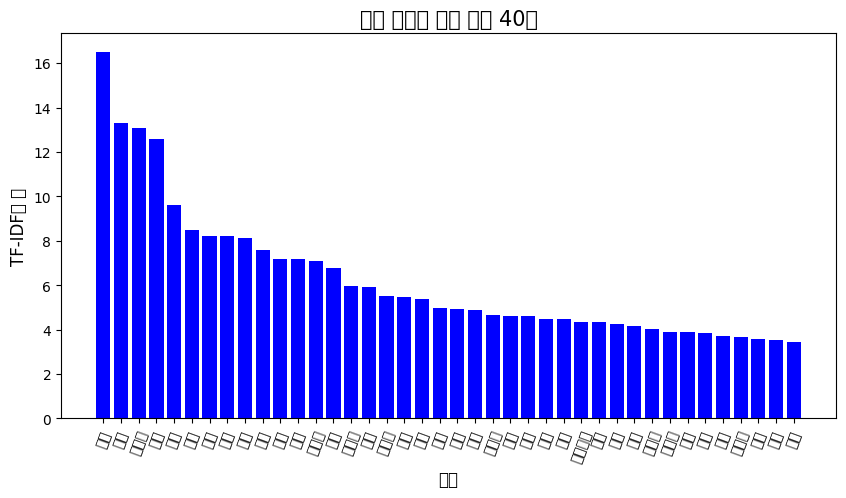

In [63]:
plt.figure(figsize=(10,5))
plt.bar(range(max), [i[1] for i in POS_words[:max]], color = "blue")
plt.title("긍정 뉴스의 단어 상위 %d개" %max, fontsize = 15)
plt.xlabel("단어", fontsize = 12)
plt.ylabel("TF-IDF의 합", fontsize = 12)
plt.xticks(range(max), [i[0] for i in POS_words[:max]], rotation = 70)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45684 (\N{HANGUL SYLLABLE NYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

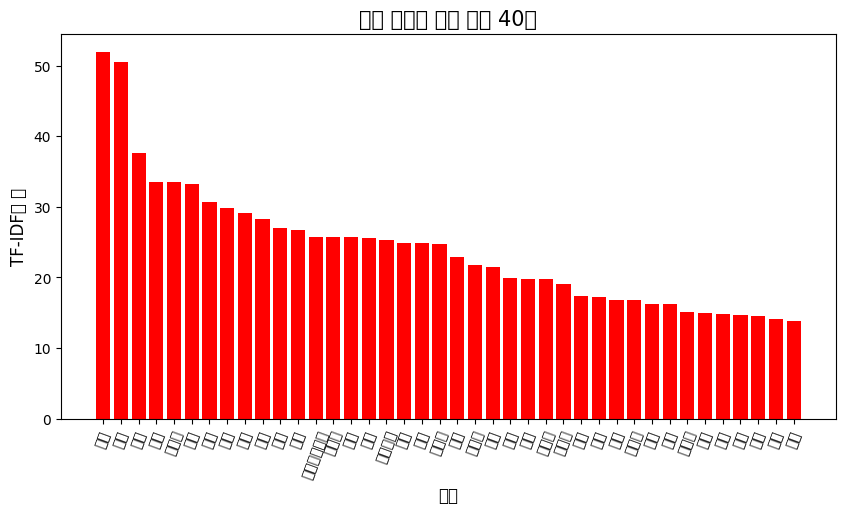

In [64]:
plt.figure(figsize=(10,5))
plt.bar(range(max), [i[1] for i in NEG_words[:max]], color = "red")
plt.title("부정 뉴스의 단어 상위 %d개" %max, fontsize = 15)
plt.xlabel("단어", fontsize = 12)
plt.ylabel("TF-IDF의 합", fontsize = 12)
plt.xticks(range(max), [i[0] for i in NEG_words[:max]], rotation = 70)
plt.show()

# 3부. 토픽모델링 : LDA 기반 토픽 모델링 ===================

# 3. 데이터 준비

In [ ]:
description = data_df['description']

In [ ]:
description_noun_tk = []

for d in description:
    description_noun_tk.append(okt.nouns(d)) #명사 형태소만 추출

In [ ]:
description_noun_tk2 = []

for d in description_noun_tk:
    item = [i for i in d if len(i) > 1] #토큰 길이가 1보다 큰 것만 추출
    description_noun_tk2.append(item)

In [ ]:
print(description_noun_tk2)  #작업 확인용 출력

[['오픈', '개발', '통해', '신제품', '아이디어', '구상', '성형', '제품', '비주', '차세대', '상품', '개발', '모델', '배스킨라빈스', '시스템', '최초', '시범', '운영', '워크샵'], ['개발', '오픈', '마이크로소프트', '대상', '성형', '훈련', '과정', '자사', '저작물', '무단', '사용', '주장', '미국', '언론사', '기업', '상대로', '저작권', '소송', '제기', '처음', '대규모', '언어', '모델'], ['유아', '초등학생', '대상', '자녀', '그림책', '예술', '융합', '상상', '놀이터', '세계', '문화유산', '왕릉', '보물', '찾기', '성인', '대상', '바로', '디자이너', '캘리그라피', '플러스'], ['도공', '참여', '공무원', '활용', '문서', '이미지', '영상', '제작', '시작', '성형', '활용', '챗봇', '제작', '도민', '서비스', '적용', '심화', '학습', '예정', '도민'], ['기반', '국방', '데이터', '활용', '활성화', '방안', '하정우', '디지털', '플랫폼', '정부', '위원회', '인공', '지능', '데이터', '분과', '위원장', '거대', '전쟁', '시대', '국방', '주제', '강연', '진행', '총장', '디지털', '전환', '첨단'], ['개발', '오픈', '공개', '인공', '지능', '영상', '제작', '프로그램', '소라', '텍스트', '동영상', '기존', '이미지', '동영상', '또한', '기존', '프로그램', '달리', '거의'], ['머스크', '테슬라', '최고경영자', '성형', '인공', '지능', '개발', '사인', '오픈', '견제구', '머스크', '앞서', '개발', '계획', '발표', '정치', '타당', '훈련'], ['인류', '현지', '시간', '머스크', '테슬라', '최고경영자', '개발', '오

# 4. 분석 모델 구축

## 4.1 토픽 분석을 위한 LDA 모델 구축하기

In [ ]:
!pip install gensim

In [ ]:
import gensim
import gensim.corpora as corpora

### LDA 토픽 모델의 입력 벡터 생성하기

In [ ]:
dictionary = corpora.Dictionary(description_noun_tk2)

In [ ]:
print(dictionary[1]) #작업 확인용 출력

구상


In [ ]:
corpus = [dictionary.doc2bow(word) for word in description_noun_tk2]

In [ ]:
print(corpus)  #작업 확인용 출력

[[(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1)], [(0, 1), (2, 1), (6, 1), (11, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1)], [(21, 2), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1)], [(6, 1), (55, 1), (56, 1), (57, 2), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 2), (67, 1), (68, 1), (69, 1), (70, 2)], [(70, 1), (71, 1), (72, 1), (73, 2), (74, 1), (75, 2), (76, 2), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1), (87, 1), (88, 1), (89, 1), (90, 1), (91, 1), (92, 1), (93, 1)], [(0, 1), (11, 1), (62, 1), (64, 1), (66, 1), (82, 1), (87, 1), (94, 1), (95, 1), (96, 2), (97,

### LDA 토픽 모델의 생성 및 훈련하기

In [ ]:
k = 5 #토픽의 개수 설정

In [ ]:
lda_model = gensim.models.ldamulticore.LdaMulticore(corpus, iterations= 12, num_topics = k,
                                                     id2word = dictionary, passes = 1, workers = 10)

# 5. 결과 확인 및 시각화

## 5.1 분석 결과 확인하기

In [ ]:
print(lda_model.print_topics(num_topics = k, num_words = 20))

[(0, '0.028*"오픈" + 0.018*"지능" + 0.014*"인공" + 0.012*"개발" + 0.012*"증권" + 0.012*"모델" + 0.010*"기술" + 0.009*"성형" + 0.008*"챗봇" + 0.008*"출시" + 0.007*"시스템" + 0.007*"스토어" + 0.007*"교육" + 0.006*"금융" + 0.006*"기반" + 0.006*"활용" + 0.006*"기업" + 0.006*"국내" + 0.006*"동영상" + 0.006*"플랫폼"'), (1, '0.027*"오픈" + 0.017*"인공" + 0.017*"지능" + 0.017*"개발" + 0.012*"성형" + 0.010*"활용" + 0.010*"시스템" + 0.009*"챗봇" + 0.008*"소라" + 0.007*"통해" + 0.006*"최근" + 0.006*"동영상" + 0.006*"서비스" + 0.006*"투자" + 0.006*"기업" + 0.006*"플랫폼" + 0.006*"공개" + 0.006*"교육" + 0.006*"시간" + 0.006*"기술"'), (2, '0.029*"개발" + 0.021*"오픈" + 0.021*"증권" + 0.015*"인공" + 0.014*"지능" + 0.014*"통해" + 0.014*"최초" + 0.014*"기술" + 0.013*"모델" + 0.013*"성형" + 0.012*"스토어" + 0.011*"챗봇" + 0.011*"시스템" + 0.011*"거래" + 0.010*"운영" + 0.010*"기반" + 0.009*"활용" + 0.009*"출시" + 0.009*"상품" + 0.008*"플랫폼"'), (3, '0.028*"오픈" + 0.025*"개발" + 0.017*"성형" + 0.016*"챗봇" + 0.012*"지능" + 0.011*"증권" + 0.011*"통해" + 0.011*"시스템" + 0.010*"최초" + 0.010*"모델" + 0.010*"인공" + 0.010*"기술" + 0.009*"스토어" + 0.008*"거래" + 0

## 5.2 분석 결과 시각화하기

In [ ]:
!pip install pyLDAvis==3.4.1

In [ ]:
import pyLDAvis.gensim

lda_vis = pyLDAvis.gensim.prepare(lda_model, corpus, dictionary)

In [ ]:
pyLDAvis.display(lda_vis)

In [ ]:
pyLDAvis.save_html(lda_vis, './13장_data/'+file_name+'_k'+str(k)+'_vis.html')